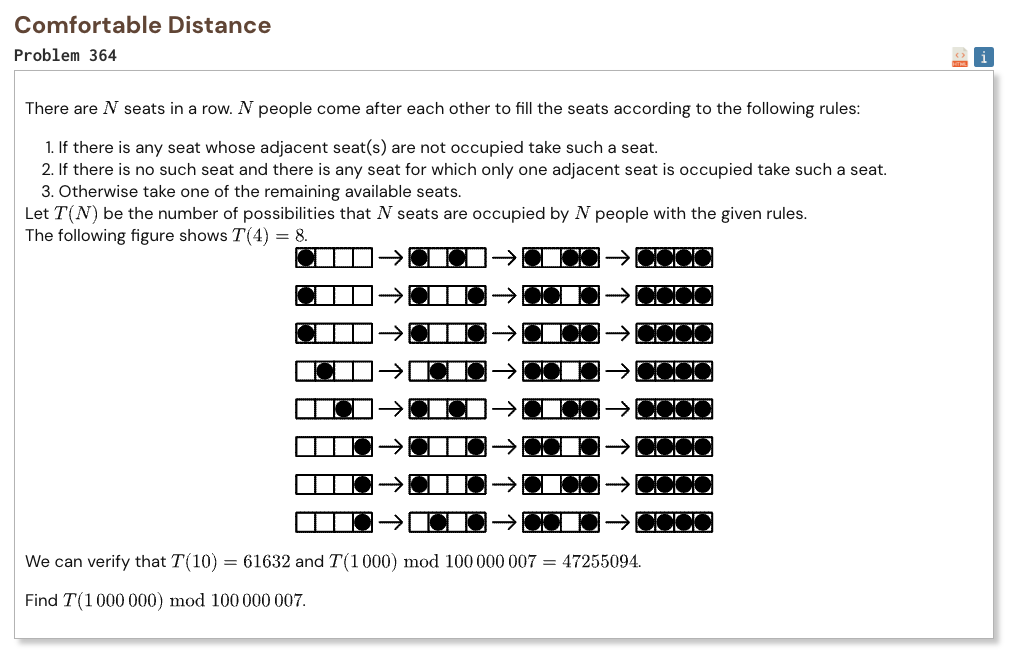

## Initial approach

* split the seating process into three phases
* first phase creates a maximal set of non-adjacent occupied seats
* the empty gaps after that can only have a few simple types
* count how many gaps have length one or two
* each gap type contributes a fixed number of later choices
* multiply by the possible orders inside each phase
* sum all valid gap patterns modulo the required number

In [1]:
import math

MOD = 100000007

def solve(n):
    fact = [1] * (n + 1)

    for i in range(1, n + 1):
        fact[i] = fact[i - 1] * i % MOD

    inv_fact = [1] * (n + 1)
    inv_fact[n] = pow(fact[n], MOD - 2, MOD)

    for i in range(n, 0, -1):
        inv_fact[i - 1] = inv_fact[i] * i % MOD

    powers_2 = [1] * (n + 1)

    for i in range(1, n + 1):
        powers_2[i] = powers_2[i - 1] * 2 % MOD

    def comb(a, b):
        if b < 0 or b > a:
            return 0

        return fact[a] * inv_fact[b] % MOD * inv_fact[a - b] % MOD

    total = 0

    for first_phase in range(1, n + 1):
        for edge_gaps in range(3):
            double_gaps = n - 2 * first_phase + 1 - edge_gaps

            if double_gaps < 0 or double_gaps > first_phase - 1:
                continue

            ways = math.comb(2, edge_gaps)
            ways = ways * comb(first_phase - 1, double_gaps) % MOD
            ways = ways * fact[first_phase] % MOD
            ways = ways * powers_2[double_gaps] % MOD
            ways = ways * fact[double_gaps + edge_gaps] % MOD
            ways = ways * fact[first_phase - 1] % MOD

            total = (total + ways) % MOD

    return total

assert solve(4) == 8
assert solve(10) == 61632

In [2]:
%%time
result = solve(1_000_000)
print("Result:", result)

Result: 44855254
CPU times: user 586 ms, sys: 20.9 ms, total: 607 ms
Wall time: 607 ms
